In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
sensors_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.000004,0.984199,0.094463,0.000373,0.999849


In [2]:
import pandas as pd
import numpy as np

# Assume your DataFrame is called df and 'Time_[s]' is the index
df = sensors_df.reset_index()  # make 'Time_[s]' a column if it's the index

def resample_experiment(group, n=46):
    # Create 46 equally spaced timestamps between min and max time
    new_times = np.linspace(group['Time_[s]'].min(), group['Time_[s]'].max(), n)
    
    # Interpolate all columns (except 'Experiment_ID') to the new timestamps
    interpolated = pd.DataFrame({'Time_[s]': new_times})
    for col in group.columns:
        if col != 'Time_[s]' and col != 'Experiment_ID':
            interpolated[col] = np.interp(new_times, group['Time_[s]'], group[col])
    
    # Keep the Experiment_ID
    interpolated['Experiment_ID'] = group['Experiment_ID'].iloc[0]
    
    return interpolated
#
# Apply to each Experiment_ID
df_resampled = df.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=46))
df_resampled = df_resampled.reset_index(drop=True)


/tmp/ipykernel_174094/260013275.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resampled = df.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=46))


In [3]:
import pandas as pd
import numpy as np

def normalize_experiment(group, n=46):
    if len(group) > n:
        # Just take the first 46 rows
        return group.iloc[:n].copy()
    else:
        # Already 46 rows
        return group.copy()

# Apply to each experiment
df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)
df_normalized = df_normalized.reset_index(drop=True)


/tmp/ipykernel_174094/900614170.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)


In [4]:
X = rf_preprocessor.group_and_pad(df_resampled, group_col="Experiment_ID")[:,:,1:]
Y = rf_preprocessor.group_and_pad(df_normalized, group_col="Experiment_ID")[:,:-1,2:]
X.shape

(100, 46, 16)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap

# ---------------------------
# 1. Model fitting and evaluation
# ---------------------------
def fit_model(X, y, model_choice="random_forest"):
    # Only multi-output safe models
    models = {
        "random_forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "gradient_boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "linear_regression": LinearRegression(),
        "ridge": Ridge(alpha=1.0),
        "lasso": Lasso(alpha=0.1),
        "elasticnet": ElasticNet(alpha=0.1, l1_ratio=0.5),
        "mlp": MLPRegressor(hidden_layer_sizes=(100,100,100), random_state=42, max_iter=3000)
    }

    if model_choice not in models:
        print(f"Model {model_choice} not found. Using random_forest instead.")
        model_choice = "random_forest"

    model = models[model_choice]
    n_exp, n_timesteps, n_features = X.shape
    n_exp, n_timesteps, n_targets = y.shape
    X = X.reshape(n_exp * n_timesteps, n_features)  # shape: (100*46, 16)
    y = y.reshape(n_exp * n_timesteps, n_targets)
    # Ensure y is 2D
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    # Fit model
    model.fit(X, y)

    # Predictions
    y_pred = model.predict(X)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    # Evaluate
    mae = mean_absolute_error(y, y_pred, multioutput="raw_values")
    r2 = r2_score(y, y_pred, multioutput="raw_values")
    
    for i, (mae_i, r2_i) in enumerate(zip(mae, r2)):
        print(f"Target {i+1}: MAE={mae_i:.4f}, R²={r2_i:.4f}")

    return model, y_pred

# ---------------------------
# 2. Compute feature window importance
# ---------------------------
def compute_feature_window_importance(X, y, model, window_size=20, stride=1, method_num=1):
    n_timesteps, n_features = X.shape
    n_feature_windows = (n_timesteps - window_size) // stride + 1
    feature_window_importance = []

    if method_num== 1:  # permutation importance
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_perm = X.copy()
                for f in range(n_features):
                    X_perm[start:end, f] = np.random.permutation(X_perm[start:end, f])

                y_hat = model.predict(X_perm)
                imp = np.mean(np.abs(y - y_hat))
                feature_window_importance.append(imp)

    elif method_num== 2:  # mean decrease impurity (only for tree-based models)
            if hasattr(model, "feature_importances_"):
                mdi_importance = model.feature_importances_
                baseline_error = mean_absolute_error(y, model.predict(X))

                for w in range(n_feature_windows):
                    start = w * stride
                    end = start + window_size
                    if end > n_timesteps:
                        break

                    y_window = y[start:end]
                    y_pred_window = model.predict(X[start:end, :])
                    window_error = mean_absolute_error(y_window, y_pred_window)
                    window_importance = np.sum(mdi_importance) * (window_error / baseline_error)
                    feature_window_importance.append(window_importance)
            else:
                raise ValueError("MDI method requires a tree-based model with feature_importances_")
            
    elif method_num== 3:  # SHAP importance
            # Compute SHAP values
            explainer = shap.Explainer(model.predict, X)
            shap_values = explainer(X)
            
            # Calculate window importance as mean absolute SHAP values per window
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break
                
                # Get SHAP values for this window and average across features and time
                window_shap = np.abs(shap_values.values[start:end, :])
                window_importance = np.mean(window_shap)
                feature_window_importance.append(window_importance)
                
    elif method_num== 4:  # leave-one-window-out importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                # Mask window with mean values
                X_masked = X.copy()
                window_means = np.mean(X[start:end, :], axis=0)
                X_masked[start:end, :] = window_means
                
                y_hat_masked = model.predict(X_masked)
                masked_error = np.mean(np.abs(y - y_hat_masked))
                imp = masked_error - baseline_error
                feature_window_importance.append(imp)
                
    elif method_num== 5:  # zero-out window importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_zero = X.copy()
                X_zero[start:end, :] = 0
                
                y_hat_zero = model.predict(X_zero)
                zero_error = np.mean(np.abs(y - y_hat_zero))
                imp = zero_error - baseline_error
                feature_window_importance.append(imp)

    elif method_num== 6:  # noise injection importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_noise = X.copy()
                noise = np.random.normal(0, 0.1, X_noise[start:end, :].shape)
                X_noise[start:end, :] += noise
                
                y_hat_noise = model.predict(X_noise)
                noise_error = np.mean(np.abs(y - y_hat_noise))
                imp = noise_error - baseline_error
                feature_window_importance.append(imp)

    elif method_num== 7:  # feature drop importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_drop = X.copy()
                X_drop[start:end, :] = np.mean(X_drop[start:end, :])
                
                y_hat_drop = model.predict(X_drop)
                drop_error = np.mean(np.abs(y - y_hat_drop))
                imp = drop_error - baseline_error
                feature_window_importance.append(imp)

    elif method_num== 8:  # partial dependence importance
            baseline_pred = model.predict(X)
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_pd = X.copy()
                # Use random values from other parts of the data
                random_indices = np.random.choice(n_timesteps, end-start)
                X_pd[start:end, :] = X[random_indices, :]
                
                y_hat_pd = model.predict(X_pd)
                pd_change = np.mean(np.abs(baseline_pred - y_hat_pd))
                feature_window_importance.append(pd_change)

    elif method_num== 9:  # variance-based importance
            baseline_pred = model.predict(X)
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_var = X.copy()
                # Scale the window to increase variance
                X_var[start:end, :] = X_var[start:end, :] * 2
                
                y_hat_var = model.predict(X_var)
                var_change = np.mean(np.abs(baseline_pred - y_hat_var))
                feature_window_importance.append(var_change)

    total_importance = np.sum(feature_window_importance)
    importance_percentages = (np.array(feature_window_importance) / total_importance) * 100
    return feature_window_importance, importance_percentages, n_feature_windows
            

# ---------------------------
# 3. Plotting
# ---------------------------
def plot_feature_windows(X, y, feature_window_importance, importance_percentages,
                         window_size=20, stride=1, num_top_windows=2, target_window_idx=0):
    
    n_timesteps, n_features = X.shape
    top_window_indices = np.argsort(feature_window_importance)[-num_top_windows:][::-1]
    target_start = target_window_idx * stride
    target_end = target_start + window_size
    timesteps = np.arange(n_timesteps)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, n_features))
    
    # Plot features
    for f in range(n_features):
        axes[0].plot(timesteps, X[:, f], marker='.', markersize=5, color=colors[f],
                     linestyle='-', alpha=0.6, label=f'Feature {f+1}')
    
    # Highlight top windows
    highlight_colors = ['red', 'orange', 'purple', 'green', 'brown', 'cyan', 'magenta', 'yellow']
    for i, window_idx in enumerate(top_window_indices):
        if i < len(highlight_colors):
            start = window_idx * stride
            end = start + window_size
            axes[0].axvspan(start, end, color=highlight_colors[i], alpha=0.4,
                            label=f'Top {i+1} ({importance_percentages[window_idx]:.1f}%)')
            mid = (start + end) / 2
            y_range = axes[0].get_ylim()
            text_y = y_range[1] - 0.05 * (y_range[1] - y_range[0]) * (i+1)
            axes[0].text(mid, text_y, f'{importance_percentages[window_idx]:.1f}%',
                         ha='center', va='center', fontweight='bold',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor=highlight_colors[i], alpha=0.8))
    
    axes[0].set_ylabel("Feature values")
    axes[0].set_title("Feature values with top important windows highlighted")
    axes[0].grid(True, alpha=0.3)
    
    # Plot target
    if y.ndim == 1:
        axes[1].plot(timesteps, y, marker='.', markersize=2, color='blue', linestyle='-', alpha=0.8, linewidth=0.5)
    else:
        for i in range(y.shape[1]):
            axes[1].plot(timesteps, y[:, i], marker='.', markersize=2, linestyle='-', alpha=0.8, label=f'Target {i+1}')
    
    axes[1].axvspan(target_start, target_end, color='grey', alpha=0.4, label='Selected target window')
    axes[1].set_xlabel("Time steps")
    axes[1].set_ylabel("Target")
    axes[1].set_title("Target values with selected window highlighted")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# ---------------------------
# 4. Additional analysis plotting
# ---------------------------
def plot_importance_analysis(feature_window_importance, importance_percentages, num_top_windows=2):
    n_feature_windows = len(feature_window_importance)
    top_window_indices = np.argsort(feature_window_importance)[-num_top_windows:][::-1]
    highlight_colors = ['red', 'orange', 'purple', 'green', 'brown', 'cyan', 'magenta', 'yellow']

    plt.figure(figsize=(14, 8))
    
    # Importance scores
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(n_feature_windows), feature_window_importance, color='skyblue', alpha=0.7)
    for i, window_idx in enumerate(top_window_indices):
        if i < len(highlight_colors):
            bars[window_idx].set_color(highlight_colors[i])
            bars[window_idx].set_alpha(0.8)
    plt.xlabel('Window Number')
    plt.ylabel('Importance Score')
    plt.title('Feature Window Importance Scores')
    plt.xticks(range(n_feature_windows))
    plt.grid(axis='y', alpha=0.3)
    


In [6]:
X_safe , y_safe= X[0],Y[0]

Target 1: MAE=0.0129, R²=0.9599
Target 2: MAE=0.0160, R²=0.9592
Target 3: MAE=0.0128, R²=0.9604


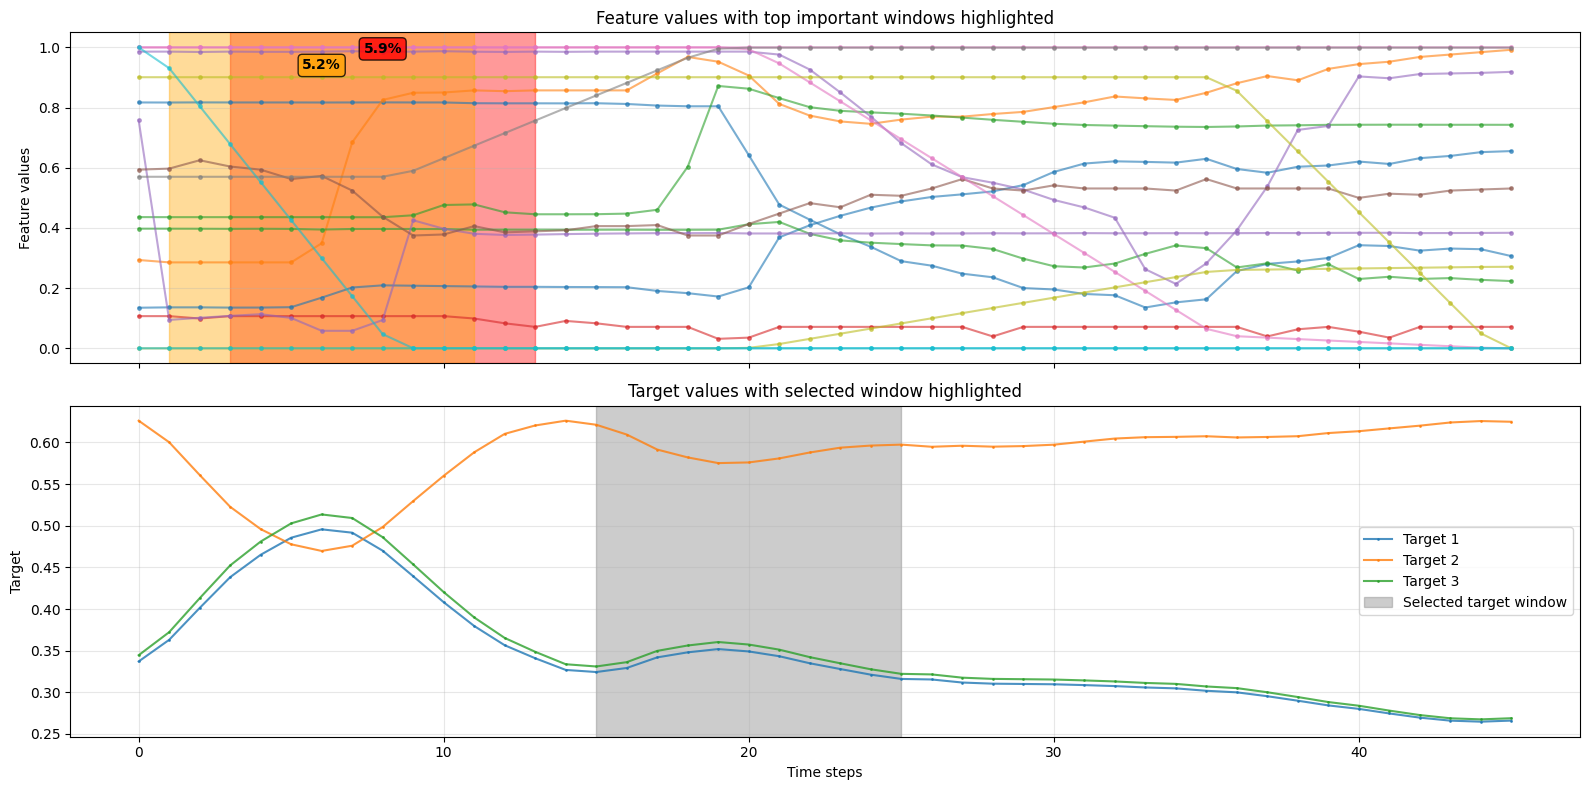

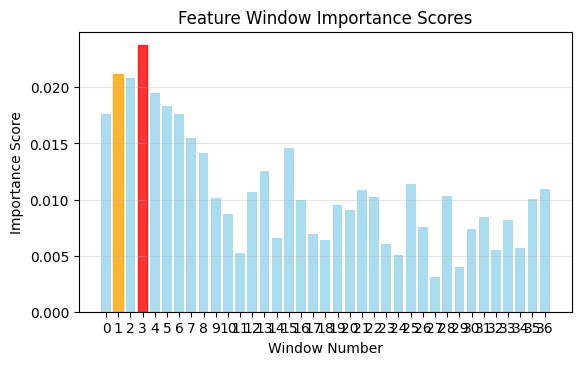

In [8]:
# ---------------------------
# Configurations
# ---------------------------
# "random_forest- 0
# "linear_regression- 2
# "ridge"- 3
# "mlp"- 6
window_size = 10
stride = 1
method_num = 8          # 1 = permutation importance, 2 = MDI (only tree-based)
num_top_windows = 2
target_window_idx = 15
model_choice = 'random_forest'

model, y_pred = fit_model(X, Y, model_choice=model_choice)
feature_window_importance, importance_percentages, n_feature_windows = compute_feature_window_importance(
    X_safe, y_safe, model,
    window_size=window_size,
    stride=stride,
    method_num=method_num
)
plot_feature_windows(
    X_safe, y_safe,
    feature_window_importance, importance_percentages,
    window_size=window_size,
    stride=stride,
    num_top_windows=num_top_windows,
    target_window_idx=target_window_idx
)
plot_importance_analysis(feature_window_importance, importance_percentages, num_top_windows=num_top_windows)
